In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Carregando o dataset
df = pd.read_csv("AmesHousing.csv")

# Visualizando as primeiras linhas
df.head()

# Informações gerais do dataset
df.info()

# Estatísticas descritivas
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [39]:
# Verificando valores nulos
df.isnull().sum().sort_values(ascending=False).head(10)

# remover colunas com muitos nulos
df = df.dropna(axis=1, thresh=len(df)*0.7)

# preencher valores numéricos com média
df.fillna(df.mean(numeric_only=True), inplace=True)

# manter apenas números (simplificação)
df = df.select_dtypes(include=['int64', 'float64'])

df.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,PriceCategory
0,1,526301100,20,141.0,31770,6,5,1960,1960,112.0,...,62,0,0,0,0,0,5,2010,215000,1
1,2,526350040,20,80.0,11622,5,6,1961,1961,0.0,...,0,0,0,120,0,0,6,2010,105000,0
2,3,526351010,20,81.0,14267,6,6,1958,1958,108.0,...,36,0,0,0,0,12500,6,2010,172000,0
3,4,526353030,20,93.0,11160,7,5,1968,1968,0.0,...,0,0,0,0,0,0,4,2010,244000,1
4,5,527105010,60,74.0,13830,5,5,1997,1998,0.0,...,34,0,0,0,0,0,3,2010,189900,1


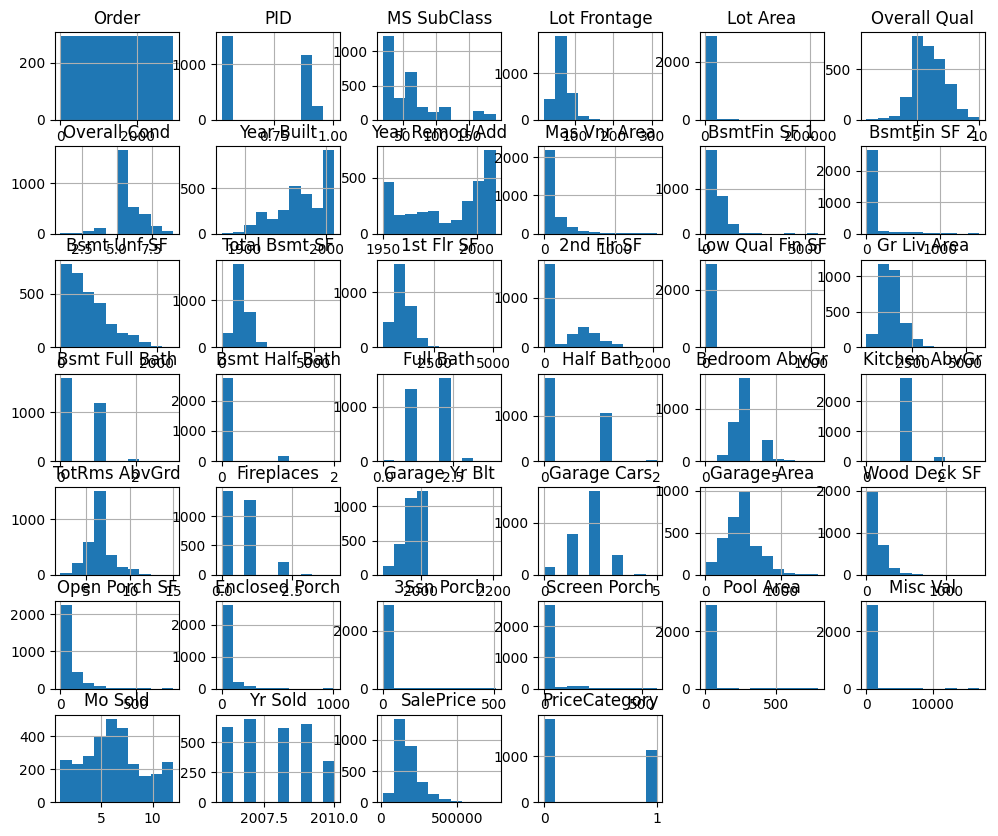

In [40]:
# Histogramas das variáveis
df.hist(figsize=(12,10))
plt.show()

In [ ]:
# Calcula a correlação entre todas as variáveis numéricas do dataset
# Seleciona apenas a correlação com a variável alvo (SalePrice)
# Ordena os valores do maior para o menor para identificar as variáveis mais influentes
corr = df.corr()["SalePrice"].sort_values(ascending=False)
corr.head(10)

SalePrice        1.000000
Overall Qual     0.799262
PriceCategory    0.750344
Gr Liv Area      0.706780
Garage Cars      0.647861
Garage Area      0.640385
Total Bsmt SF    0.632105
1st Flr SF       0.621676
Year Built       0.558426
Full Bath        0.545604
Name: SalePrice, dtype: float64

In [ ]:
# Criando nova variável
df["TotalArea"] = df["Gr Liv Area"] + df["Total Bsmt SF"]

In [86]:
# Separação de variáveis
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Treinamento do modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Previsão
y_pred = model.predict(X_test)

In [87]:
# Métricas de regressão
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 21512.321692959445
RMSE: 36017.48138328626
R²: 0.8381975416455671


In [57]:
# Criando variável categórica
df["PriceCategory"] = (df["SalePrice"] > df["SalePrice"].mean()).astype(int)

# Separação
X = df.drop(["SalePrice", "PriceCategory"], axis=1)
y = df["PriceCategory"]

# Normalizando os dados (IMPORTANTE para KNN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9334470989761092
Precision: 0.926829268292683
Recall: 0.9156626506024096
F1: 0.9212121212121213
Matriz de Confusão:
[[319  18]
 [ 21 228]]


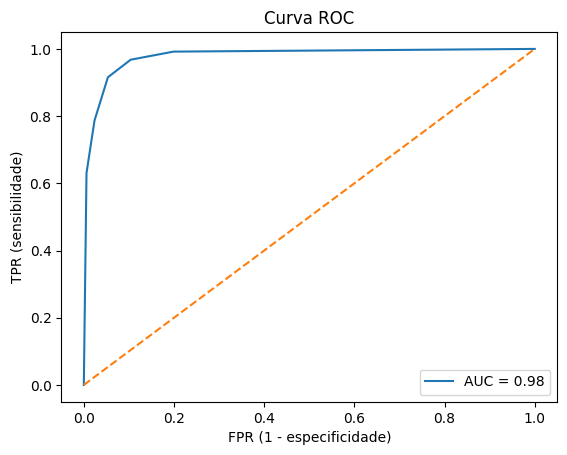

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidade da classe positiva (classe 1)
y_prob = knn.predict_proba(X_test)[:,1]

# Calculando curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculando AUC
auc = roc_auc_score(y_test, y_prob)

# Plotando gráfico
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("FPR (1 - especificidade)")
plt.ylabel("TPR (sensibilidade)")
plt.title("Curva ROC")
plt.legend()
plt.show()